# **6.2 图像卷积**

直接看例子。

![https://zh.d2l.ai/_images/correlation.svg](https://zh.d2l.ai/_images/correlation.svg)

输出维度变化为输入维度减去卷积核维度（边缘作用） 
$$
n_h \times n_w - k_h \times k_w = (n_h-k_h+1) \times (n_w-k_w+1)
$$ 
下面实现这个过程并完成运算

In [7]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # 临时绕过 OpenMP 重复加载冲突

import torch
from torch import nn
from d2l import torch as d2l

def corr2d(X, K):  #@save
    """计算二维互相关运算"""
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(X.shape[0] - h + 1):
        for j in range(X.shape[1] - w + 1):
            Y[i, j] = (X[i:i+h, j:j+w] * K).sum()
    return Y

X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
corr2d(X, K)

tensor([[19., 25.],
        [37., 43.]])

实现一个卷积层，完成前向传播

In [8]:
class Conv2D(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.weight = nn.Parameter(torch.rand(kernel_size))
        self.bias = nn.Parameter(torch.zeros(1))
        ##形状为(1,)，随后会被广播成输出的形状

    def forward(self, x):
        return corr2d(x, self.weight) + self.bias

## 6.2.1 边缘检测

通过设定参数及方向卷积层可以用作某种图像工具，如边缘检测器。现在实现一个横向的检测器，把1视为黑色，0为白色。输出中1为黑到白边缘，-1为白到黑边缘

In [9]:
X = torch.ones((6, 8))
X[:, 2:6] = 0
X

tensor([[1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.]])

In [10]:
K = torch.tensor([[1.0, -1.0]])
Y = corr2d(X, K)
Y

tensor([[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.]])

画出来。

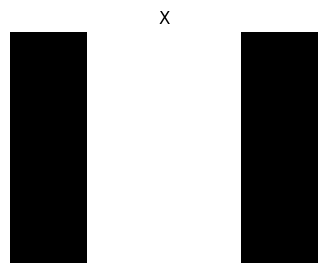

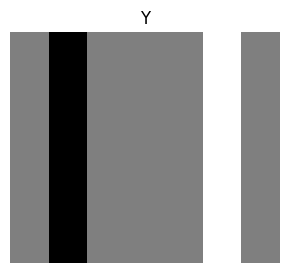

In [11]:
import matplotlib.pyplot as plt

def show_tensor_bw(t, title=""):
    """将2D张量按其当前数值范围绘制为黑白图。"""
    img = t.detach().cpu().squeeze()
    if img.ndim != 2:
        raise ValueError("show_tensor_bw 仅支持2D张量")

    vmin = float(img.min())
    vmax = float(img.max())
    if vmin == vmax:
        vmax = vmin + 1e-6

    plt.figure(figsize=(5, 3))
    plt.imshow(img, cmap="gray_r", vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.axis("off")
    plt.show()

show_tensor_bw(X, "X")
show_tensor_bw(Y, "Y")

## 6.2.2 学习卷积核

接下来要搞一个能够进行参数迭代的卷积核以实现“学习”能力

In [12]:
# 构造一个二维卷积层，它具有1个输出通道和形状为（1，2）的卷积核
conv2d = nn.Conv2d(1,1, kernel_size=(1, 2), bias=False)

# 这个二维卷积层使用四维输入和输出格式（批量大小、通道、高度、宽度），
# 其中批量大小和通道数都为1
X = X.reshape((1, 1, 6, 8))
Y = Y.reshape((1, 1, 6, 7))
lr = 3e-2  # 学习率

for i in range(10):
    Y_hat = conv2d(X)
    l = (Y_hat - Y) ** 2
    conv2d.zero_grad()
    l.sum().backward()
    # 迭代卷积核
    conv2d.weight.data[:] -= lr * conv2d.weight.grad
    if (i + 1) % 2 == 0:
        print(f'epoch {i+1}, loss {l.sum():.3f}')

epoch 2, loss 3.315
epoch 4, loss 0.583
epoch 6, loss 0.109
epoch 8, loss 0.023
epoch 10, loss 0.006


In [13]:
conv2d.weight.data.reshape((1, 2))

tensor([[ 0.9964, -0.9850]])

学得不错

## 6.2.3 特征映射和感受野

输出的卷积层可以视作上一层的特征到低维空间的一个映射。感受野（receptive field）是指在前向传播期间可能影响$x$计算的所有元素（来自所有先前层）。可以理解为一个作为多层映射结果的$x$在不同层上的自变量的集合。

$$
x = \tau_1(y_{(1, 1)}, \dots, y_{(1, j_1)}) = \tau_2(y_{(2, 1)}, \dots, y_{(2, j_2)}) = \dots = \tau_k(y_{(k, 1)}, \dots, y_{(k, j_k)})
$$
设 $x$ 对第 $i$ 层的感受野为 $\Omega_{x, i}$, 则
$$
\Omega_{x, i} = \{ y_{(i, j)} | j \in {j_1, \dots, j_i} \}
$$

不难发现，越到深层，维度逐渐降低，每个元素的感受野原来越大，相当于信息逐渐收敛、汇总，映射为最后的目标，最后的输出。显然，若为回答“图像是否包含一只猫”这类问题，最后的输出的感受野就是所有的输入，即对整个输入全局敏感。